## Generative model of decision-making under risk

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [95]:
# Utility function of engaging in rule-breaking behavior
def utility_function(x_ij, gamma_i):
    """
    Calculate the utility of engaging in rule-breaking behavior.
    Parameters:
    x_ij (float): The amount of money.
    gamma_i (float): The risk aversion parameter.
    Returns:
    float: The utility of engaging in rule-breaking behavior.
    """
    
    if gamma_i <= 0:
        raise ValueError("gamma_i must be positive")
    
    return np.sign(x_ij) * (np.abs(x_ij))**(1 - gamma_i)


In [3]:
# Prelec's probability weighting function

def prelec(p_ij, beta_i, alpha_i):
    """
    Prelec's (1998) probability weighting function.
    
    Parameters:
    p_ij (ixj array): Probability value in the range [0, 1].
    alpha_i (float): Parameter that determines the curvature of the weighting function.
    
    Returns:
    float: Weighted probability.
    """
    if p_ij < 0 or p_ij > 1:
        raise ValueError("x must be in the range [0, 1]")
    
    if alpha_i <= 0:
        raise ValueError("alpha must be positive")
    
    return np.exp(-beta_i*(-np.log(p_ij))**alpha_i)

In [ ]:
def decision(A,B,C, theta, p_ij, gamma_i, beta_i, alpha_i):
    """
    Decision-making function to determine whether to engage in rule-breaking behavior.
    
    Parameters:
    A (float): Instant benefit from rule-breaking behavior.
    B (float): Instant benefit of not engaging in rule-breaking behavior.
    C (float): Cost of engaging in rule-breaking behavior.
    theta (float): Initial wealth of the individual.
    p_ij (float): Probability of being caught engaging in rule-breaking behavior.
    gamma_i (float): Risk aversion parameter.
    beta_i (float): Likelihood sensitivity parameter for Prelec's probability weighting function.
    alpha_i (float): Optimism/pessimism parameter for Prelec's probability weighting function.
    
    Returns:
    str: Decision outcome.
    """
    
    # Calculate expected utility of engaging in rule-breaking behavior
    # (u(θ+A)-u(θ-c))/(u(θ+B)-u(θ-c) )
    EU_rule_breaking = ( (prelec(p_ij, beta_i, alpha_i)) * (utility_function(A + theta, gamma_i) )  ) - ( (1-prelec(p_ij, beta_i, alpha_i)) * utility_function(theta - C, gamma_i) )
    
    # Calculate expected utility of not engaging in rule-breaking behavior
    EU_no_rule_breaking = utility_function(B + theta, gamma_i)
    
    if EU_rule_breaking > EU_no_rule_breaking:
        return "Engage in rule-breaking behavior"
    else:
        return "Do not engage in rule-breaking behavior"


In [98]:
def EU_rule_break(A,C, theta, p_ij, gamma_i, beta_i, alpha_i):
    """
    Decision-making function to determine whether to engage in rule-breaking behavior.
    
    Parameters:
    A (float): Instant benefit from rule-breaking behavior.
    B (float): Instant benefit of not engaging in rule-breaking behavior.
    C (float): Cost of engaging in rule-breaking behavior.
    theta (float): Initial wealth of the individual.
    p_ij (float): Probability of being caught engaging in rule-breaking behavior.
    gamma_i (float): Risk aversion parameter.
    beta_i (float): Likelihood sensitivity parameter for Prelec's probability weighting function.
    alpha_i (float): Optimism/pessimism parameter for Prelec's probability weighting function.
    
    Returns:
    str: Decision outcome.
    """
    
    # Calculate expected utility of engaging in rule-breaking behavior
    # w(p)u(θ+A)-(1-w(p))u(θ-c)
    EU_rule_breaking = ( (prelec(p_ij, beta_i, alpha_i)) * (utility_function(A + theta, gamma_i) )  ) - ( (1-prelec(p_ij, beta_i, alpha_i)) * utility_function(theta - C, gamma_i) )
    
    return EU_rule_breaking


In [99]:
def EU_follow_rules(B, theta, gamma_i):
    """
    Decision-making function to determine whether to engage in rule-breaking behavior.
    
    Parameters:
    B (float): Instant benefit of not engaging in rule-breaking behavior.
    theta (float): Initial wealth of the individual.
    p_ij (float): Probability of being caught engaging in rule-breaking behavior.
    gamma_i (float): Risk aversion parameter.
    
    Returns:
    float: Expected utility.
    """
    
    # Calculate expected utility of not engaging in rule-breaking behavior
    EU_no_rule_breaking = utility_function(B + theta, gamma_i)
    
    return EU_no_rule_breaking


## Varying gamma (uncertainty aversion) while holding all other variables constant

In [100]:

gammas = np.linspace(0.1, 5, 100)
all_EU_rb = []
all_EU_no_rb = []

for gamma in gammas:
    EU_rb = EU_rule_break(A=500, C=25, theta=50, p_ij=0.1, gamma_i=gamma, beta_i=1.9, alpha_i=0.8)
    EU_no_rb = EU_follow_rules(B=25, theta=50, gamma_i=gamma)
    all_EU_rb.append(EU_rb)
    all_EU_no_rb.append(EU_no_rb)


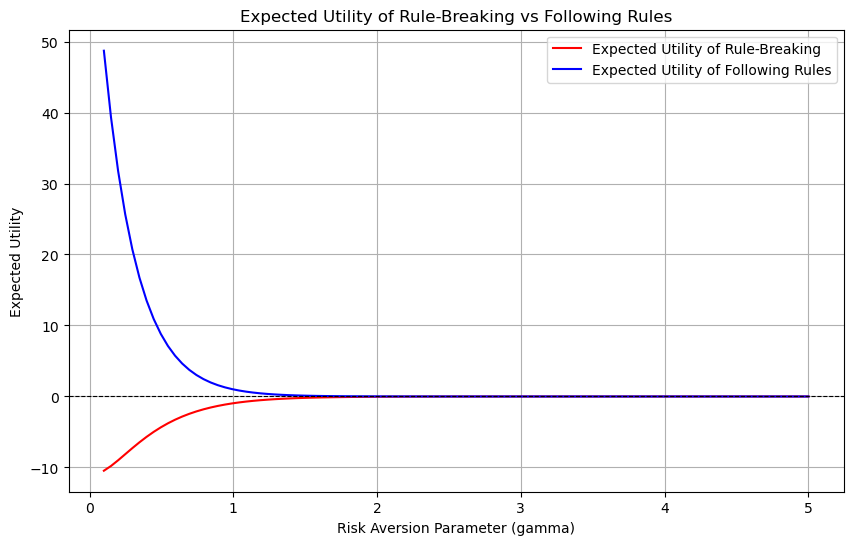

In [101]:
# plot the expected utilities
plt.figure(figsize=(10, 6))
plt.plot(gammas, all_EU_rb, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(gammas, all_EU_no_rb, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules')
plt.xlabel('Risk Aversion Parameter (gamma)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying A (instant benefit of rule breaking behavior) while holding all other variables constant

In [38]:
As = np.linspace(10, 50000, 100)
all_EU_rbA = []
all_EU_no_rbA = []

for a in As:
    EU_rb = EU_rule_break(A=a, C=50, theta=60, p_ij=0.1, gamma_i=0.5, beta_i=1.9, alpha_i=0.8)
    EU_no_rb = EU_follow_rules(B=25, theta=60, gamma_i=gamma)
    all_EU_rbA.append(EU_rb)
    all_EU_no_rbA.append(EU_no_rb)

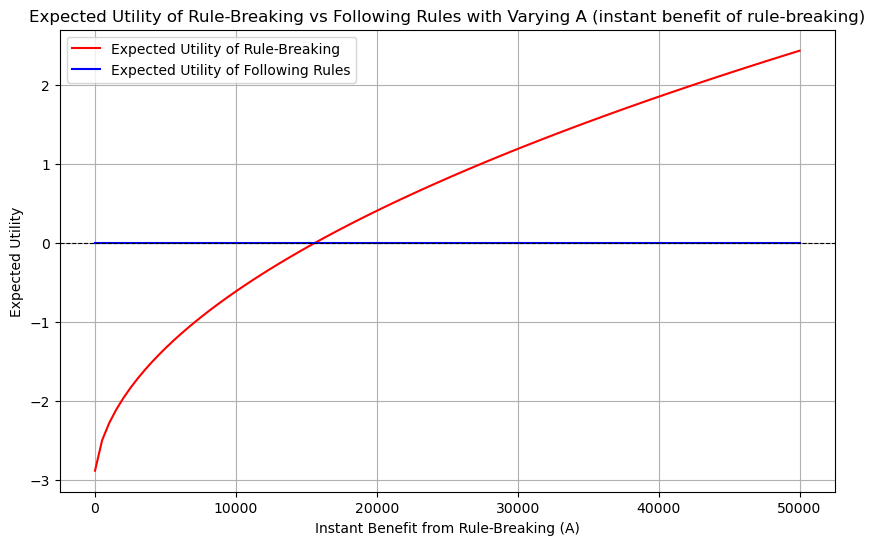

In [39]:
# plotting the results
plt.figure(figsize=(10, 6))
plt.plot(As, all_EU_rbA, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(As, all_EU_no_rbA, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying A (instant benefit of rule-breaking)') 
plt.xlabel('Instant Benefit from Rule-Breaking (A)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying B (instant benefit of not engaging in rule-breaking behavior) while holding all other variables constant

In [73]:
B = np.linspace(0, 500, 100)
all_EU_rbB = []
all_EU_no_rbB = []
for b in B:
    EU_rb = EU_rule_break(A=1000, C=50, theta=100, p_ij=0.05, gamma_i=0.5, beta_i=1.9, alpha_i=0.8)
    EU_no_rb = EU_follow_rules(b, theta=100, gamma_i=gamma)
    all_EU_rbB.append(EU_rb)
    all_EU_no_rbB.append(EU_no_rb)

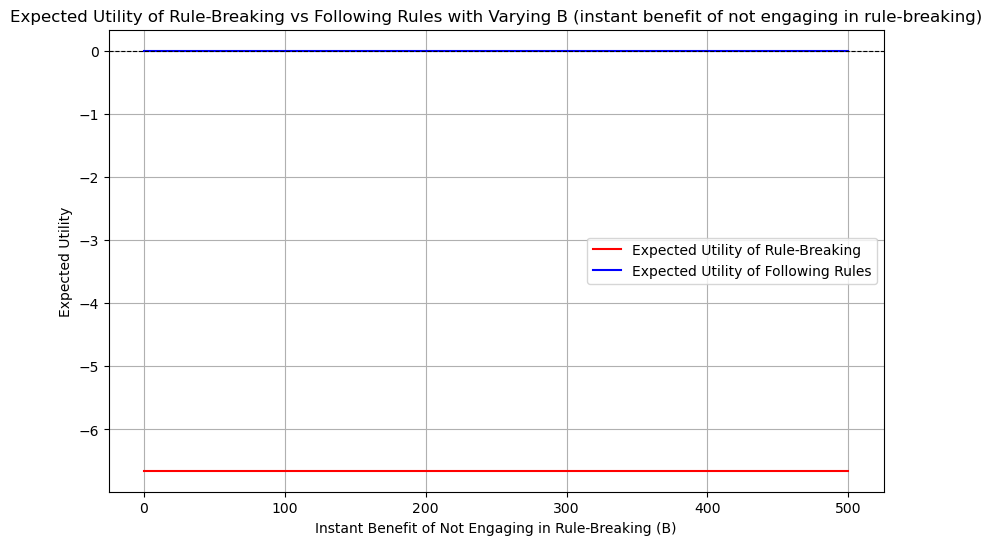

In [74]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(B, all_EU_rbB, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(B, all_EU_no_rbB, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying B (instant benefit of not engaging in rule-breaking)')
plt.xlabel('Instant Benefit of Not Engaging in Rule-Breaking (B)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying C (Cost of engaging in rule-breaking behavior) while holding all other variables constant

In [104]:
C = np.linspace(10, 500, 100)
all_EU_rbC = []
all_EU_no_rbC = []
for c in C:
    EU_rb = EU_rule_break(A=1000, C=c, theta=100, p_ij=0.05, gamma_i=0.5, beta_i=1.9, alpha_i=0.8)
    EU_no_rb = EU_follow_rules(B=25, theta=100, gamma_i=gamma)
    all_EU_rbC.append(EU_rb)
    all_EU_no_rbC.append(EU_no_rb)

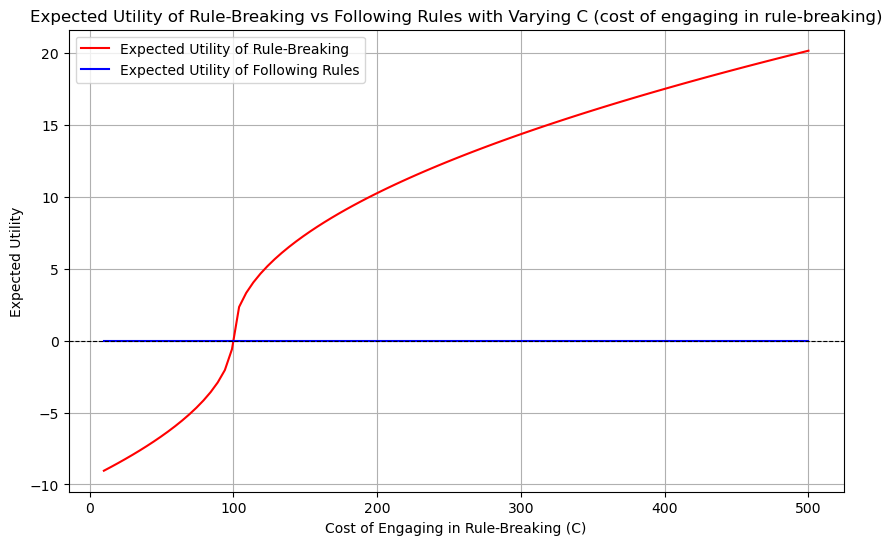

In [106]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(C, all_EU_rbC, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(C, all_EU_no_rbC, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying C (cost of engaging in rule-breaking)')
plt.xlabel('Cost of Engaging in Rule-Breaking (C)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()


## Varying theta (initial wealth) while holding all other variables constant

In [111]:
theta = np.linspace(10, 100, 100)
all_EU_rbtheta = []
all_EU_no_rbtheta = []
for t in theta:
    EU_rb = EU_rule_break(A=1000, C=50, theta=t, p_ij=0.05, gamma_i=0.5, beta_i=1.9, alpha_i=0.8)
    EU_no_rb = EU_follow_rules(B=25, theta=t, gamma_i=gamma)
    all_EU_rbtheta.append(EU_rb)
    all_EU_no_rbtheta.append(EU_no_rb)

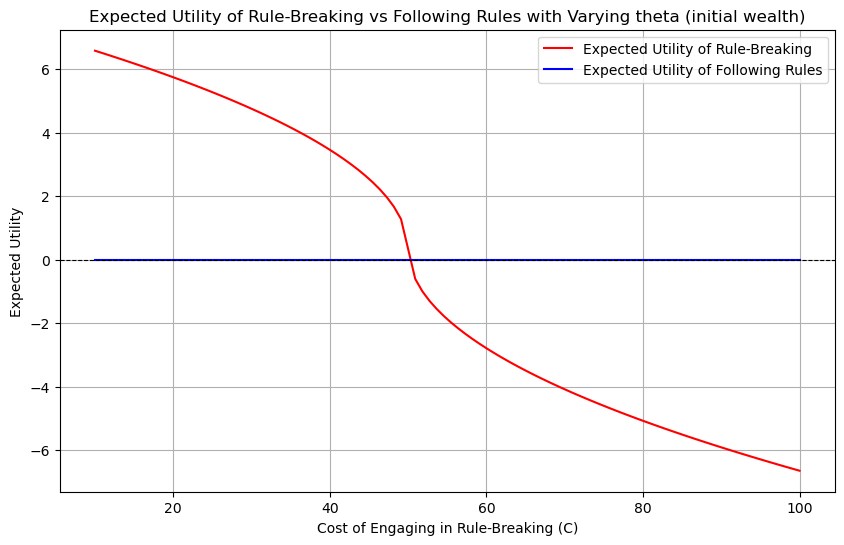

In [112]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(theta, all_EU_rbtheta, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(theta, all_EU_no_rbtheta, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying theta (initial wealth)')
plt.xlabel('Cost of Engaging in Rule-Breaking (C)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying alpha (likelihood insensitivity) while holding all other variables constant
Values closer to 0 indicate thst the person is more insensitive and does not distinguish likelihoods well

In [123]:
alpha = np.linspace(0.01, 3, 100)
all_EU_rbalpha = []
all_EU_no_rbalpha = []
for a in alpha:
    EU_rb = EU_rule_break(A=1000, C=50, theta=50, p_ij=0.05, gamma_i=0.5, beta_i=1.9, alpha_i=a)
    EU_no_rb = EU_follow_rules(B=25, theta=50, gamma_i=0.5)
    all_EU_rbalpha.append(EU_rb)
    all_EU_no_rbalpha.append(EU_no_rb)

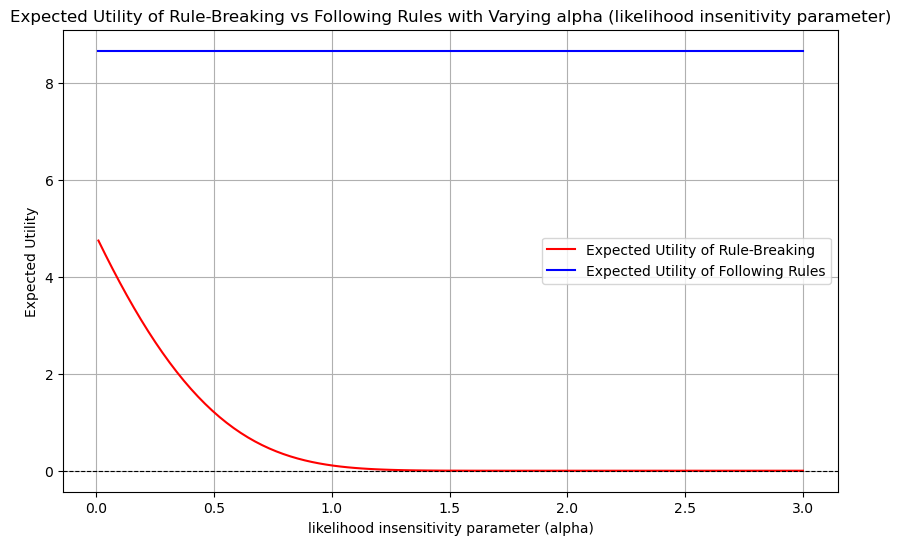

In [124]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(alpha, all_EU_rbalpha, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(alpha, all_EU_no_rbalpha, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying alpha (likelihood insenitivity parameter)')
plt.xlabel('likelihood insensitivity parameter (alpha)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying beta (optimism/pessimism) while holding all other variables constant
beta < 1 indicates pessimism, while beta > 1 indicates optimism

In [121]:
beta = np.linspace(0.01, 3, 100)
all_EU_rbbeta = []
all_EU_no_rbbeta = []
for b in beta:
    EU_rb = EU_rule_break(A=1000, C=50, theta=50, p_ij=0.05, gamma_i=0.5, beta_i=b, alpha_i=0.8)
    EU_no_rb = EU_follow_rules(B=25, theta=50, gamma_i=0.5)
    all_EU_rbbeta.append(EU_rb)
    all_EU_no_rbbeta.append(EU_no_rb)

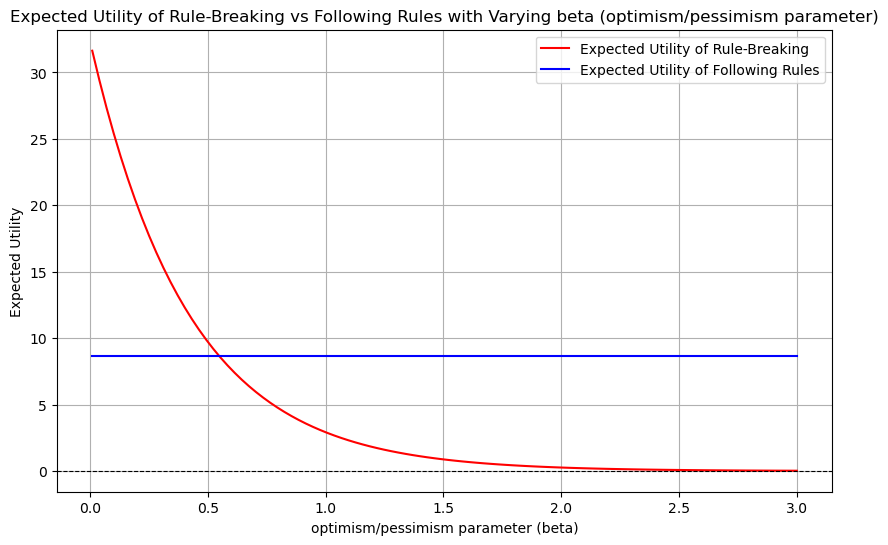

In [122]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(beta, all_EU_rbbeta, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(beta, all_EU_no_rbbeta, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying beta (optimism/pessimism parameter)')
plt.xlabel('optimism/pessimism parameter (beta)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()

## Varying p_ij (probability of being caught) while holding all other variables constant

In [125]:
ps = np.linspace(0.01, 1, 100)
all_EU_rbp_ij = []
all_EU_no_rbp_ij = []
for p in ps:
    EU_rb = EU_rule_break(A=1000, C=50, theta=50, p_ij=p, gamma_i=0.5, beta_i=1.9, alpha_i=0.8)
    EU_no_rb = EU_follow_rules(B=25, theta=50, gamma_i=0.5)
    all_EU_rbp_ij.append(EU_rb)
    all_EU_no_rbp_ij.append(EU_no_rb)

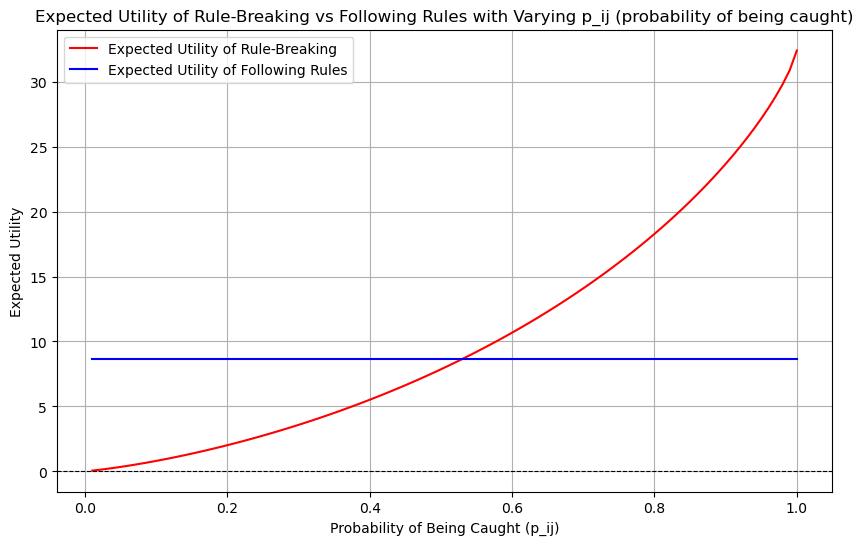

In [126]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(ps, all_EU_rbp_ij, label='Expected Utility of Rule-Breaking', color='red')
plt.plot(ps, all_EU_no_rbp_ij, label='Expected Utility of Following Rules', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Expected Utility of Rule-Breaking vs Following Rules with Varying p_ij (probability of being caught)')
plt.xlabel('Probability of Being Caught (p_ij)')
plt.ylabel('Expected Utility')
plt.legend()
plt.grid()
plt.show()